<a href="https://colab.research.google.com/github/192424111simats-debug/CV-STVDlab/blob/main/CVLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving WhatsApp Image 2026-04-27 at 1.09.06 PM.jpeg to WhatsApp Image 2026-04-27 at 1.09.06 PM.jpeg


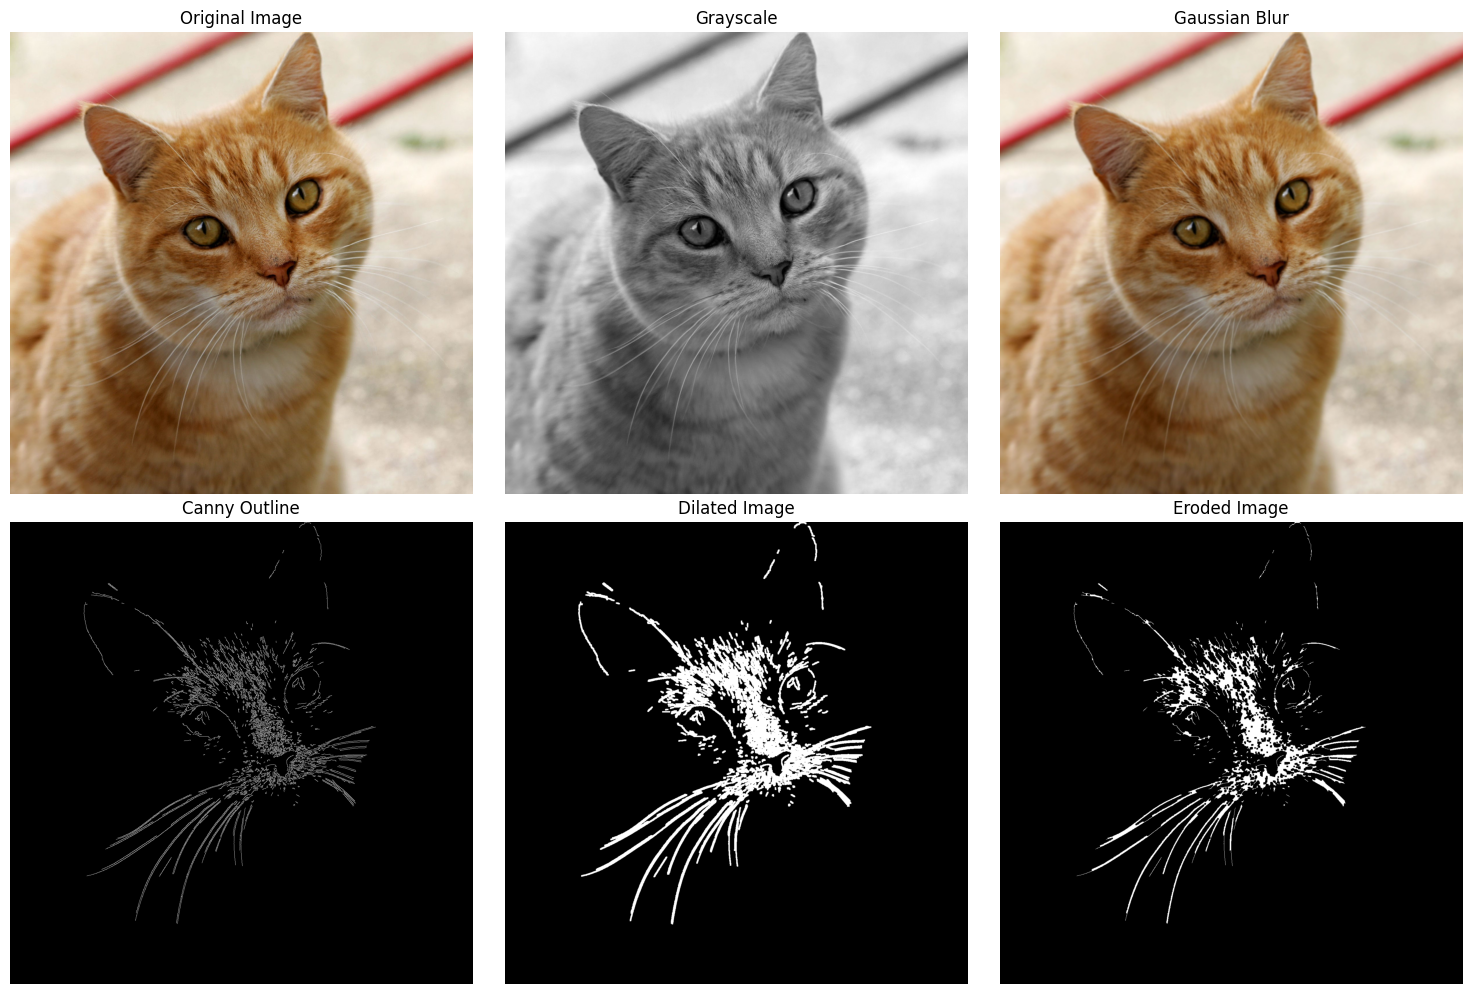

In [ ]:
# ============================================
# Basic Image Handling & Processing in Colab
# Upload Image -> Grayscale -> Blur -> Canny -> Dilate -> Erode
# ============================================

# Install / Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------
# Step 1: Upload Image
# --------------------------------------------
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read Image
img = cv2.imread(image_path)

# Convert BGR to RGB (for displaying correctly in matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --------------------------------------------
# a) Convert to Grayscale
# --------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --------------------------------------------
# b) Gaussian Blur
# --------------------------------------------
blur = cv2.GaussianBlur(img, (7,7), 0)

# --------------------------------------------
# c) Canny Edge Detection (Outline)
# --------------------------------------------
canny = cv2.Canny(img, 100, 200)

# --------------------------------------------
# d) Dilate Image
# --------------------------------------------
kernel = np.ones((5,5), np.uint8)
dilate = cv2.dilate(canny, kernel, iterations=1)

# --------------------------------------------
# e) Erode Image
# --------------------------------------------
erode = cv2.erode(dilate, kernel, iterations=1)

# --------------------------------------------
# Display All Results
# --------------------------------------------
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(canny, cmap='gray')
plt.title("Canny Outline")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(dilate, cmap='gray')
plt.title("Dilated Image")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(erode, cmap='gray')
plt.title("Eroded Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Video Processing in Google Colab
# Normal / Slow / Fast Motion
# ============================================

import cv2
from google.colab import files
from IPython.display import HTML, display
from base64 import b64encode

# --------------------------------------------
# Upload Video
# --------------------------------------------
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# --------------------------------------------
# Function to Display Video in Colab
# speed:
# 1.0 = normal
# 0.5 = slow
# 2.0 = fast
# --------------------------------------------
def show_video(video_path, speed=1.0):
    video_file = open(video_path, "rb").read()
    video_url = "data:video/mp4;base64," + b64encode(video_file).decode()

    html_code = f"""
    <video width="640" controls playbackRate="{speed}">
      <source src="{video_url}" type="video/mp4">
    </video>
    <script>
      var v = document.querySelector("video");
      v.playbackRate = {speed};
    </script>
    """
    display(HTML(html_code))

# --------------------------------------------
# Normal Speed
# --------------------------------------------
print("Normal Speed Video")
show_video(video_path, speed=1.0)

# --------------------------------------------
# Slow Motion
# --------------------------------------------
print("Slow Motion Video")
show_video(video_path, speed=0.5)

# --------------------------------------------
# Fast Motion
# --------------------------------------------
print("Fast Motion Video")
show_video(video_path, speed=2.0)